In [6]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [10]:
#load dataset
url = "/content/adult.csv"
df = pd.read_csv(url)

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [12]:
df.shape, df.columns

((32561, 15),
 Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
        'marital.status', 'occupation', 'relationship', 'race', 'sex',
        'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
        'income'],
       dtype='object'))

In [13]:
#define features and target
X = df.drop('income', axis=1)
y = (df['income'] == '>50K').astype(int)

X.head(), y.head()


(   age workclass  fnlwgt     education  education.num marital.status  \
 0   90         ?   77053       HS-grad              9        Widowed   
 1   82   Private  132870       HS-grad              9        Widowed   
 2   66         ?  186061  Some-college             10        Widowed   
 3   54   Private  140359       7th-8th              4       Divorced   
 4   41   Private  264663  Some-college             10      Separated   
 
           occupation   relationship   race     sex  capital.gain  \
 0                  ?  Not-in-family  White  Female             0   
 1    Exec-managerial  Not-in-family  White  Female             0   
 2                  ?      Unmarried  Black  Female             0   
 3  Machine-op-inspct      Unmarried  White  Female             0   
 4     Prof-specialty      Own-child  White  Female             0   
 
    capital.loss  hours.per.week native.country  
 0          4356              40  United-States  
 1          4356              18  United-Sta

In [14]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

cat_cols, num_cols


(Index(['workclass', 'education', 'marital.status', 'occupation',
        'relationship', 'race', 'sex', 'native.country'],
       dtype='object'),
 Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
        'hours.per.week'],
       dtype='object'))

In [15]:
#preprocessing + pipeline
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

model = Pipeline([
    ('prep', preprocess),
    ('tree', DecisionTreeClassifier(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)



In [16]:
accuracy_score(y_test, y_pred)

0.8182004299314157

In [17]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

precision, recall, f1

(0.6214470284237726, 0.6166666666666667, 0.6190476190476191)

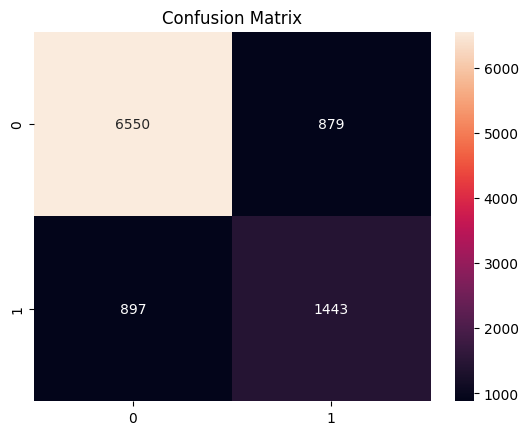

In [18]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [19]:
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

scores.mean(), scores.std()

(np.float64(0.7638592593682414), np.float64(0.027977680045014743))

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities for the positive class
y_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

ROC AUC Score: 0.7492


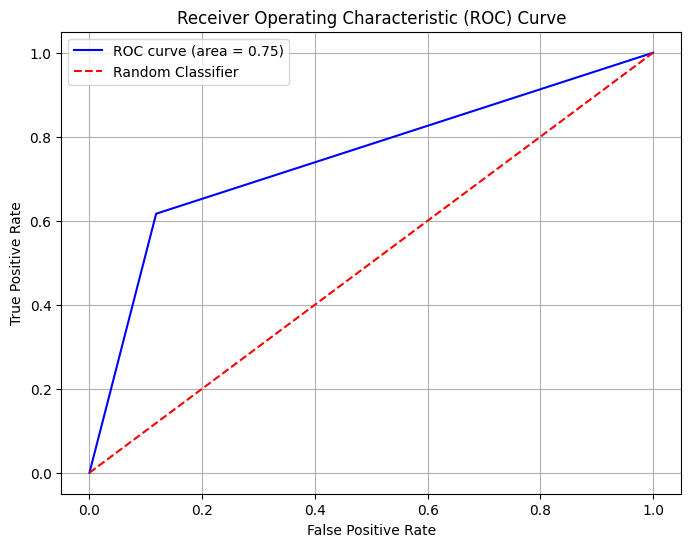

In [22]:
# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

Accuracy: Your model achieved an accuracy of approximately 81.82% on the test set. This means that about 81.82% of all predictions made by the model were correct (both positive and negative classes).

Precision: The precision score is ~62.14%. Precision measures the proportion of positive identifications that were actually correct. In your case, when the model predicted '>50K income', it was correct about 62.14% of the time.

Recall: The recall score is ~61.67%. Recall (also known as sensitivity) measures the proportion of actual positives that were identified correctly. So, your model correctly identified about 61.67% of all individuals who actually had '>50K income'.

F1-Score: The F1-score is ~61.90%. This is the harmonic mean of precision and recall, providing a single metric that balances both. It's particularly useful when you have an uneven class distribution.

Confusion Matrix: The matrix [[6550, 879], [897, 1443]] can be interpreted as follows:

True Negatives (TN): 6550 - The model correctly predicted 6550 instances as '<=50K income'.
False Positives (FP): 879 - The model incorrectly predicted 879 instances as '>50K income' when they were actually '<=50K income'.
False Negatives (FN): 897 - The model incorrectly predicted 897 instances as '<=50K income' when they were actually '>50K income'.
True Positives (TP): 1443 - The model correctly predicted 1443 instances as '>50K income'.


Cross-Validation Scores: The 5-fold cross-validation resulted in an average accuracy of ~76.39% with a standard deviation of ~2.80%. This indicates that the model's performance is reasonably consistent across different subsets of your data, but there's a slight drop compared to the initial test set accuracy. The standard deviation suggests that the accuracy doesn't vary too wildly between folds, which is a good sign of model stability.

The ROC AUC score of 0.7492 indicates that your model has a reasonable ability to distinguish between the two income classes, performing better than random guessing. This score represents a 74.92% chance that the model will correctly rank a randomly chosen positive instance higher than a randomly chosen negative instance. The ROC curve plot further illustrates this, showing that your model's performance (blue line) is well above that of a random classifier (red dashed line), confirming its predictive power.